# CTM-Based Song Recommendation System (GPU-Optimized)

This notebook implements a GPU-accelerated music recommendation pipeline using Contextualized Topic Models (CTM). It covers:

1. **GPU Setup & Detection** - Automatically detect and configure GPU usage
2. **Data Preprocessing** - Cleaning and tokenizing song lyrics for CTM input
3. **GPU-Accelerated CTM Training** - Training CombinedTM with CUDA acceleration
4. **GPU-Accelerated Embedding Generation** - Using GPU for sentence transformers
5. **Topic Labeling** - Generating interpretable topic names with LangChain + OpenAI
6. **Evaluation** - Computing topic coherence and diversity metrics
7. **Similarity Calculation** - Building song/artist vectors with GPU acceleration
8. **Diversity-Aware Recommendations** - Applying Maximal Marginal Relevance (MMR)

## 🚀 GPU Optimizations:
- **Automatic GPU detection** and fallback to CPU
- **CUDA-accelerated** SentenceTransformer embeddings
- **GPU-optimized** CTM training
- **Batch processing** for large datasets
- **Memory management** to avoid GPU OOM errors


In [70]:
# ===== GPU SETUP AND DETECTION =====
import warnings
import os
# Comprehensive warning suppression
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings(
    "ignore", message=".*ipykernel.comm.Comm.*", category=DeprecationWarning)
warnings.filterwarnings(
    "ignore", message=".*csr_matrix.*scipy.sparse.csr.*", category=DeprecationWarning)

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTHONWARNINGS"] = "ignore"

from enum import Enum
from dotenv import load_dotenv
from langchain.prompts import PromptTemplate
from langchain.schema import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from scipy.spatial.distance import cosine
import re
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import nltk
from sentence_transformers import SentenceTransformer
from contextualized_topic_models.utils.preprocessing import WhiteSpacePreprocessing
from contextualized_topic_models.utils.data_preparation import TopicModelDataPreparation
from contextualized_topic_models.models.ctm import CombinedTM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime
from contextualized_topic_models.utils.preprocessing import (
    WhiteSpacePreprocessingStopwords,
)
from nltk.corpus import stopwords as stop_words
import torch
import gc
from contextualized_topic_models.evaluation.measures import (
    CoherenceNPMI,
    TopicDiversity,
    CoherenceCV,
)
from contextualized_topic_models.datasets.dataset import CTMDataset
import pyLDAvis as vis
from difflib import SequenceMatcher
import lyricsgenius
import warnings
import random




# Set random seeds for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)


def setup_gpu_environment():
    """Setup GPU environment with proper memory management"""
    # Check CUDA availability

    cuda_available = torch.cuda.is_available()
    device_count = torch.cuda.device_count()
    print("🖥️  GPU Environment Setup:")
    print(f"   CUDA Available: {cuda_available}")

    if cuda_available:
        print(f"   GPU Device Count: {device_count}")
        for i in range(device_count):
            gpu_name = torch.cuda.get_device_name(i)
            gpu_memory = torch.cuda.get_device_properties(i).total_memory / 1024**3
            print(f"   GPU {i}: {gpu_name} ({gpu_memory:.1f} GB)")

        # Set memory management

        torch.cuda.empty_cache()

        # Set memory fraction to avoid OOM

        torch.cuda.set_per_process_memory_fraction(0.8)
        device = torch.device("cuda")
        print(f"   ✅ Using GPU: {torch.cuda.get_device_name(0)}")

    else:
        device = torch.device("cpu")
        print("   ⚠️  CUDA not available. Using CPU.")
        print(
            "   💡 To enable GPU: pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118"
        )

    # Set environment variables for optimal performance
    os.environ["TOKENIZERS_PARALLELISM"] = "false"  # Avoid warnings
    return device, cuda_available

def clear_gpu_memory():
    """Clear GPU memory cache"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()
        print("🧹 GPU memory cleared")



def get_gpu_memory_usage():
    """Get current GPU memory usage"""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        cached = torch.cuda.memory_reserved() / 1024**3
        return f"GPU Memory - Allocated: {allocated:.2f} GB, Cached: {cached:.2f} GB"
    return "GPU not available"



# Initialize GPU environment
device, cuda_available = setup_gpu_environment()
print(f"\n🎯 Device selected: {device}")

🖥️  GPU Environment Setup:
   CUDA Available: True
   GPU Device Count: 1
   GPU 0: NVIDIA GeForce RTX 3050 Laptop GPU (4.0 GB)
   ✅ Using GPU: NVIDIA GeForce RTX 3050 Laptop GPU

🎯 Device selected: cuda


In [71]:
# NLTK downloads
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

print("📦 All libraries imported successfully!")

# Load OpenAI API key
load_dotenv(override=True)
openai_api_key = os.getenv("OPENAI_API_KEY")
if not openai_api_key:
    print("⚠️ OpenAI API key not found. LLM-based labeling will be disabled.")

print(f"\n{get_gpu_memory_usage()}")

📦 All libraries imported successfully!

GPU Memory - Allocated: 1.76 GB, Cached: 1.90 GB


In [72]:
# ===== DATA LOADING =====

# Load your song lyrics dataset
data_path = "../Lyrics_extraction/scraped_lyrics_no_metadata_combined.csv"
df = pd.read_csv(data_path)

def clean_lyrics_for_ctm(text):
    # Remove structural markers like [Chorus], [Verse], etc.
    text = re.sub(r'\[.*?\]', '', text)
    
    # Clean up whitespace and newlines
    text = re.sub(r'\n+', ' ', text)  # Replace newlines with spaces
    text = re.sub(r'\s+', ' ', text)  # Normalize whitespace    
    
    return text.strip()

df['lyrics'] = df['lyrics'].apply(clean_lyrics_for_ctm)

print(f"📊 Dataset Overview:")
print(f"   Songs: {len(df):,}")
print(f"   Artists: {df['artist'].nunique():,}")
print(f"   Columns: {list(df.columns)}")

# Display sample data
print("\n🎵 Sample songs:")
df.head(5)

📊 Dataset Overview:
   Songs: 5,949
   Artists: 600
   Columns: ['artist', 'song_title', 'lyrics']

🎵 Sample songs:


,artist,song_title,lyrics
0,21 Savage,Bank Account,"Ooh, ooh, oh, oh, oh, ow, ow Wow, wow, wow, ah..."
1,21 Savage,Ghostface Killers,"Metro Boomin want some more, nigga (Hey) Autom..."
2,21 Savage,Glock in My Lap,"Y'all niggas stop playin', nigga Y'all niggas ..."
3,21 Savage,No Heart,"Southside, Southside on the, Southside on the,..."
4,21 Savage,Red Opps,"Yeah, yeah, yeah I pull up roll the window dow..."


In [73]:
df_sample = pd.read_csv("../Lyrics_extraction/scraped_lyrics.csv")
df_sample.sample(5, random_state=42)


,artist,song_title,lyrics
1801,Michael Jackson,Billie Jean,272 ContributorsTranslationsEspañolPortuguêsעב...
1190,Jackson 5,ABC,60 ContributorsABC Lyrics“ABC” is the lead sin...
1817,Miley Cyrus,Used To Be Young,49 ContributorsTranslationsالعربيةDeutschPortu...
251,Beyoncé,Drunk in Love,430 ContributorsTranslationsPortuguêsFrançaisE...
2505,Spice Girls,Stop,25 ContributorsStop Lyrics“Stop” is a Motown i...


In [74]:
# ===== GPU-OPTIMIZED PREPROCESSING =====


nltk.download("stopwords")
stopwords = list(stop_words.words("english"))
documents = df['lyrics'].tolist()
sp = WhiteSpacePreprocessingStopwords(documents,stopwords_list=stopwords, vocabulary_size=14000)
preprocessed_documents, unpreprocessed_corpus, vocab, retained_indices = sp.preprocess()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [75]:
print(f"\n📄 Preprocessing complete:"
      f"\n   Retained {len(retained_indices):,} out of {len(documents):,} documents"
      f"\n   Vocabulary size: {len(vocab):,}"
      f"\n   Sample preprocessed document: {preprocessed_documents[0][:100]}...")

print(f"\n Unprerprocessed documents samplen: {unpreprocessed_corpus[0][:100]}...")


📄 Preprocessing complete:
   Retained 5,946 out of 5,949 documents
   Vocabulary size: 13,935
   Sample preprocessed document: ooh ooh oh oh oh ow ow wow wow wow ah ow ow ow buy new car bitch real tear mall bitch real even talk...

 Unprerprocessed documents samplen: Ooh, ooh, oh, oh, oh, ow, ow Wow, wow, wow, ah, ow, ow, ow I buy a new car for the bitch (For real) ...


In [76]:
valid_idx = set(retained_indices)
invalid_idx = set(range(len(df))) - valid_idx

for i in invalid_idx:
    df.drop(i, inplace=True)

print(f"Number of invalid indices: {len(invalid_idx)}")
print(len(df))


Number of invalid indices: 3
5946


In [77]:
clear_gpu_memory()
# Create TopicModelDataPreparation object
print("🔧 Preparing CTM training data...")

# sentence_transformers_model = "all-mpnet-base-v2"
sentence_transformers_model_name = "distiluse-base-multilingual-cased-v1"

tp = TopicModelDataPreparation(sentence_transformers_model_name, show_warning=False) 
training_dataset = tp.fit(
    text_for_contextual=unpreprocessed_corpus,
    text_for_bow=preprocessed_documents, 
)

print(f"   Using Sentence Transformers model: {sentence_transformers_model_name}")
print(f"✅ CTM data prepared!")
print(f"   BoW vocabulary size: {len(tp.vocab):,}")

print(f"\n{get_gpu_memory_usage()}")

🧹 GPU memory cleared
🔧 Preparing CTM training data...


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

   Using Sentence Transformers model: distiluse-base-multilingual-cased-v1
✅ CTM data prepared!
   BoW vocabulary size: 13,935

GPU Memory - Allocated: 0.75 GB, Cached: 2.27 GB


In [78]:
# ===== GPU-ACCELERATED CTM TRAINING =====
warnings.filterwarnings('ignore')

def train_ctm_with_gpu(training_dataset: CTMDataset, tp, n_topics=10, num_epochs=20, 
                      learning_rate=0.002, batch_size=200, n_samples=2000):
    """Train CTM model with GPU acceleration"""

    print(f"🚀 Training CombinedTM with {n_topics} topics...")
    print(f"   Epochs: {num_epochs}")
    print(f"   Learning rate: {learning_rate}")
    print(f"   Batch size: {batch_size}")
    print(f"   Samples: {n_samples}")
    contextual_size = len(training_dataset.X_contextual[0])
    # Initialize CTM model
    ctm = CombinedTM(
        bow_size=len(tp.vocab),
        contextual_size=contextual_size,
        learn_priors=True,
        n_components=n_topics,
        num_epochs=num_epochs,
        batch_size=batch_size,
        num_data_loader_workers=0 if cuda_available else 2,  # Avoid multiprocessing issues on GPU
        reduce_on_plateau=True,  # Enable learning rate reduction
    )

    # Set device for CTM training
    if cuda_available:
        print(f"   ✅ Training on GPU: {torch.cuda.get_device_name(0)}")
    else:
        print(f"   ⚠️  Training on CPU")

    # Clear memory before training
    clear_gpu_memory()

    # Train the model
    print("⏳ Training in progress...")
    start_time = datetime.now()

    try:
        ctm.fit(training_dataset)

        end_time = datetime.now()
        training_time = (end_time - start_time).total_seconds()

        print(f"✅ CTM training completed in {training_time:.1f} seconds!")
        print(f"   Average time per epoch: {training_time/num_epochs:.1f} seconds")

    except Exception as e:
        print(f"❌ Training failed: {str(e)}")
        clear_gpu_memory()
        raise

    return ctm

# Optimize parameters based on available hardware
if cuda_available:
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    n_topics = 10
    batch_size = 300
    n_samples = 3000
  
else:
    n_topics = 10
    batch_size = 100
    n_samples = 1000

print(f"\n{get_gpu_memory_usage()}")
print(f"🎯 Optimized parameters: {n_topics} topics, batch size {batch_size}, {n_samples} samples")

# Train the CTM model
ctm = train_ctm_with_gpu(
    training_dataset, 
    tp, 
    n_topics=n_topics,
    num_epochs=10,
    batch_size=batch_size,
    n_samples=n_samples
)

print(f"\n{get_gpu_memory_usage()}")


GPU Memory - Allocated: 0.75 GB, Cached: 2.27 GB
🎯 Optimized parameters: 10 topics, batch size 300, 3000 samples
🚀 Training CombinedTM with 10 topics...
   Epochs: 10
   Learning rate: 0.002
   Batch size: 300
   Samples: 3000
   ✅ Training on GPU: NVIDIA GeForce RTX 3050 Laptop GPU
🧹 GPU memory cleared
⏳ Training in progress...


Epoch: [10/10]	 Seen Samples: [57000/59460]	Train Loss: 1495.6511129385965	Time: 0:00:03.139135: : 10it [00:31,  3.18s/it]
Sampling: [20/20]: : 20it [01:01,  3.10s/it]

✅ CTM training completed in 93.8 seconds!
   Average time per epoch: 9.4 seconds

GPU Memory - Allocated: 0.24 GB, Cached: 1.04 GB


📊 Analyzing discovered topics...
⟶ CV coherence (avg): 0.5615
⟶ CV coherence (per topic): [0.5819639939583752, 0.5037164496923798, 0.5674745037128134, 0.6516597348530373, 0.5073906290046375, 0.9748256885085926, 0.47415380936118395, 0.3438959650918827, 0.5001394663128005, 0.5101993210284876]
⟶ Topic Diversity: 0.8200


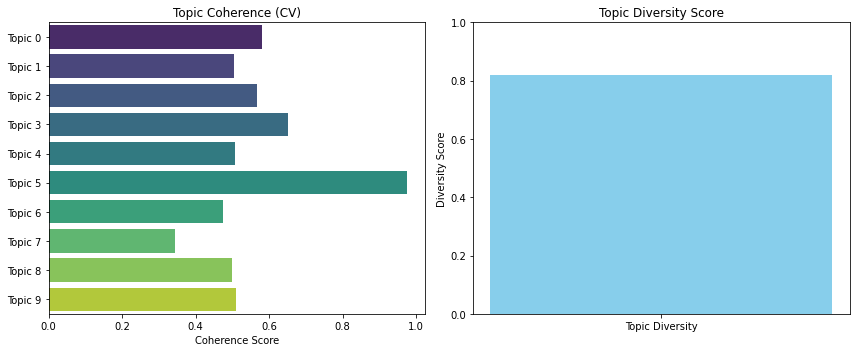

🧹 GPU memory cleared

GPU Memory - Allocated: 0.24 GB, Cached: 0.56 GB


In [79]:

# ===== TOPIC ANALYSIS AND EVALUATION =====

print("📊 Analyzing discovered topics...")

# Get topic-word distributions
topics = ctm.get_topic_lists(20)

# 2. load your pre‐processed “bag-of-words” texts
#    this must be a List[List[str]] — exactly what you passed as `text_for_bow` to TopicModelDataPreparation
texts = [
    doc.split()  # if you saved each preprocessed doc as a space‐joined string
    for doc in preprocessed_documents
] #List of list of str

# 3. import the CTM evaluation classes

# 4. compute NPMI coherence (a popular, normalized PMI metric)
npmi = CoherenceNPMI(topics=topics, texts=texts)
cv = CoherenceCV(topics=topics, texts= texts)
coherence_score = cv.score(topk=10)                   # average over topics
coherence_per_topic = cv.score(topk=10, per_topic=True)  # list of per‐topic scores

print(f"⟶ CV coherence (avg): {coherence_score:.4f}")
print(f"⟶ CV coherence (per topic): {coherence_per_topic}")

# 5. compute topic diversity (proportion of unique top‐words across topics)
diversity = TopicDiversity(topics=topics)
diversity_score = diversity.score(topk=20)

print(f"⟶ Topic Diversity: {diversity_score:.4f}")

# Plotting coherence
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
labels = [f"Topic {i}" for i in range(len(topics))]
sns.barplot(x=coherence_per_topic, y=labels, orient='h', palette='viridis')
plt.title('Topic Coherence (CV)')
plt.xlabel('Coherence Score')

plt.subplot(1, 2, 2)
plt.bar(['Topic Diversity'], [diversity_score], color='skyblue')
plt.title('Topic Diversity Score')
plt.ylabel('Diversity Score')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# Memory cleanup
clear_gpu_memory()
print(f"\n{get_gpu_memory_usage()}")

In [80]:

warnings.filterwarnings('ignore')

lda_vis_data = ctm.get_ldavis_data_format(tp.vocab, training_dataset, n_samples=10)

ctm_pd = vis.prepare(**lda_vis_data)
vis.save_html(data=ctm_pd, fileobj='ctm_vis.html')
vis.display(ctm_pd)

Sampling: [10/10]: : 10it [00:30,  3.05s/it]


In [81]:
# ===== LLM-ASSISTED TOPIC LABELING =====




def generate_topic_labels_with_llm(topics, max_topics=20):
    """Generate human-readable topic labels using LangChain + OpenAI GPT."""
    print("🤖 Generating human-readable topic labels with LLM...")

    if not openai_api_key:
        print("⚠️ OpenAI API key not found. Using fallback labels.")
        return {i: f"Topic {i}" for i in range(len(topics))}

    try:
        llm = ChatOpenAI(
            model="gpt-4o",
            temperature=0.0,  # Set to 0 for consistent outputs
            max_tokens=80,    # Reduced for more concise labels
            api_key=openai_api_key,
            seed=42,          # For reproducible outputs
            top_p=1.0,        # Use full probability distribution
        )
        print("   ✅ Connected to OpenAI GPT-4o")
    except Exception as e:
        print(f"   ❌ Failed to connect to OpenAI: {e}")
        return {i: f"Topic {i}" for i in range(len(topics))}

    prompt_template = PromptTemplate.from_template(
        """You are a music expert. Based on these keywords for a song topic: '{topic_words}', 
        provide a concise, human-readable topic label (2-4 words). Try to use generic (general) words to capture the topics and avoid using proper nouns for a certain place, human,...etc.  Topic Label:"""
    )

    topic_labels = {}
    for topic_id, topic_words in enumerate(topics[:max_topics]):
        try:
            prompt = prompt_template.format(topic_words=", ".join(topic_words))
            response = llm([HumanMessage(content=prompt)])
            label = response.content.strip()
            topic_words_data = ctm.get_word_distribution_by_topic_id(topic_id)[:20]
            topic_words = [word for word, _ in topic_words_data]
            print(f"   Topic {topic_id:2d}: '{label}' ")
            print(f"      Keywords: {', '.join(topic_words)}...")  # Show first 5 words for brevity
            topic_labels[topic_id] = {
                'label': label,
                'words': topic_words,
                'word_probabilities': topic_words_data,
                'confidence': 'llm_generated',
                'raw_response': response.content
            }
        except Exception as e:
            print(f"Topic {topic_id}")
            print(f"   ❌ Failed to generate label for topic {topic_id}: {e}")
    return topic_labels


# Generate labels
topic_labels = generate_topic_labels_with_llm(topics, max_topics=n_topics)
print("✅ Topic labeling complete!")

🤖 Generating human-readable topic labels with LLM...
   ✅ Connected to OpenAI GPT-4o
   Topic  0: 'Cultural Exploration Journey' 
      Keywords: error, cassette, lighters, girlie, troy, travellin, gza, tested, attempt, demonstration, stereotype, satin, thai, tourist, scriptures, oyster, missile, 미칠, hitler, auntie...
   Topic  1: 'Travel and Communication Mishaps' 
      Keywords: banged, error, pla, gniht, washin, exclusive, nana, cassette, manager, constantly, msayin, tradition, ziploc, italy, nonsense, jose, pics, outnumbered, travellin, 끝낸...
   Topic  2: 'Cultural Juxtaposition Themes' 
      Keywords: pilf, pushin, cleaner, banged, tradition, jamrock, phil, shocking, troy, scribble, fills, 않죠, hitler, scores, switches, cigarettes, highness, auntie, 똑바로, 매번...
   Topic  3: 'Street Life Struggles' 
      Keywords: niggas, like, bitch, got, fuck, get, cause, know, shit, hit, nigga, uh, see, man, ass, fuckin, back, tryna, one, money...
   Topic  4: 'Romantic Longing and Desire' 
   

In [82]:
# ===== SONG AND ARTIST TOPIC DISTRIBUTIONS =====
warnings.filterwarnings("ignore")
print("📊 Calculating topic distributions for songs...")
song_topic_distributions = ctm.get_thetas(training_dataset, n_samples=5)
df['main_topic'] = np.argmax(song_topic_distributions, axis=1)
df['main_topic_probability'] = np.max(song_topic_distributions, axis=1)
df['topic_distribution'] = list(song_topic_distributions)
print("✅ Song topic distributions calculated.")

print(df.head(10))

📊 Calculating topic distributions for songs...


Sampling: [5/5]: : 5it [00:12,  2.45s/it]

✅ Song topic distributions calculated.
      artist              song_title  \
0  21 Savage            Bank Account   
1  21 Savage       Ghostface Killers   
2  21 Savage         Glock in My Lap   
3  21 Savage                No Heart   
4  21 Savage                Red Opps   
5  21 Savage                       X   
6  21 Savage                   a lot   
7  21 Savage            ball w/o you   
8  21 Savage  can’t leave without it   
9  21 Savage                 monster   

                                              lyrics  main_topic  \
0  Ooh, ooh, oh, oh, oh, ow, ow Wow, wow, wow, ah...           8   
1  Metro Boomin want some more, nigga (Hey) Autom...           3   
2  Y'all niggas stop playin', nigga Y'all niggas ...           8   
3  Southside, Southside on the, Southside on the,...           3   
4  Yeah, yeah, yeah I pull up roll the window dow...           8   
5  Ten bad bitches in a mansion Wrist on Milly Ro...           3   
6  I love you Turn my headphone down a littl

📊 Creating visualizations for songs per topic...
Topic distribution:
main_topic
0    690
1    657
2    593
3    369
4    851
5    393
6    743
7    587
8    741
9    322
Name: count, dtype: int64


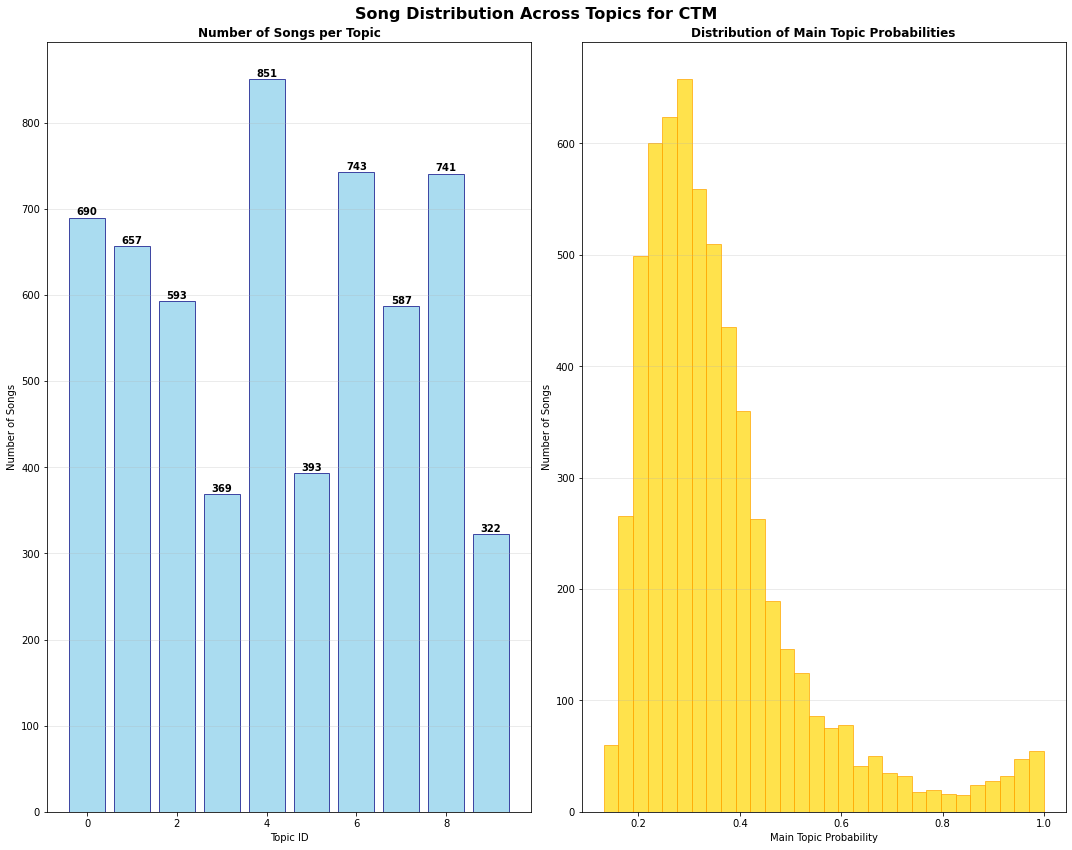


📈 TOPIC STATISTICS:
Total number of songs: 5946
Number of topics: 10
Average songs per topic: 594.6
Most popular topic: Topic 0 (690 songs)
Least popular topic: Topic 9 (322 songs)

Topic Probability Statistics:
Mean probability: 0.358
Median probability: 0.317
Min probability: 0.131
Max probability: 0.999

High confidence assignments (>0.8): 215 songs
Low confidence assignments (<0.3): 2589 songs

⚖️ TOPIC BALANCE ANALYSIS:
Topic distribution percentages:
Topic 0: 11.6% (690 songs) - ✅ Balanced
Topic 1: 11.0% (657 songs) - ✅ Balanced
Topic 2: 10.0% (593 songs) - ✅ Balanced
Topic 3: 6.2% (369 songs) - ✅ Balanced
Topic 4: 14.3% (851 songs) - ✅ Balanced
Topic 5: 6.6% (393 songs) - ✅ Balanced
Topic 6: 12.5% (743 songs) - ✅ Balanced
Topic 7: 9.9% (587 songs) - ✅ Balanced
Topic 8: 12.5% (741 songs) - ✅ Balanced
Topic 9: 5.4% (322 songs) - ✅ Balanced

Topic Distribution Gini Coefficient: 0.160
(0 = perfectly equal, 1 = perfectly unequal)
✅ Topics are well-balanced


In [83]:

# ===== VISUALIZE SONGS PER TOPIC =====

print("📊 Creating visualizations for songs per topic...")

# Count songs per topic
topic_counts = df['main_topic'].value_counts().sort_index()
print(f"Topic distribution:\n{topic_counts}")

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 12))
fig.suptitle('Song Distribution Across Topics for CTM', fontsize=16, fontweight='bold')

# 1. Bar plot - Songs per topic
axes[0].bar(topic_counts.index, topic_counts.values,
               color='skyblue', edgecolor='navy', alpha=0.7)
axes[0].set_title('Number of Songs per Topic', fontweight='bold')
axes[0].set_xlabel('Topic ID')
axes[0].set_ylabel('Number of Songs')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(topic_counts.values):
    axes[0].text(topic_counts.index[i], v + 0.5, str(v),
                    ha='center', va='bottom', fontweight='bold')


# 2. Topic probability distribution
axes[1].hist(df['main_topic_probability'], bins=30,
                color='gold', edgecolor='orange', alpha=0.7)
axes[1].set_title(
    'Distribution of Main Topic Probabilities', fontweight='bold')
axes[1].set_xlabel('Main Topic Probability')
axes[1].set_ylabel('Number of Songs')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ===== DETAILED STATISTICS =====

print("\n📈 TOPIC STATISTICS:")
print("=" * 50)
print(f"Total number of songs: {len(df)}")
print(f"Number of topics: {df['main_topic'].nunique()}")
print(f"Average songs per topic: {len(df) / df['main_topic'].nunique():.1f}")
print(
    f"Most popular topic: Topic {topic_counts.index[0]} ({topic_counts.iloc[0]} songs)")
print(
    f"Least popular topic: Topic {topic_counts.index[-1]} ({topic_counts.iloc[-1]} songs)")

# Topic probability statistics
print(f"\nTopic Probability Statistics:")
print(f"Mean probability: {df['main_topic_probability'].mean():.3f}")
print(f"Median probability: {df['main_topic_probability'].median():.3f}")
print(f"Min probability: {df['main_topic_probability'].min():.3f}")
print(f"Max probability: {df['main_topic_probability'].max():.3f}")

# Show topics with very high/low confidence
high_confidence = df[df['main_topic_probability'] > 0.8]
low_confidence = df[df['main_topic_probability'] < 0.3]

print(f"\nHigh confidence assignments (>0.8): {len(high_confidence)} songs")
print(f"Low confidence assignments (<0.3): {len(low_confidence)} songs")

# ===== TOPIC BALANCE ANALYSIS =====

print("\n⚖️ TOPIC BALANCE ANALYSIS:")
print("=" * 50)

# Calculate topic balance metrics
topic_percentages = (topic_counts / len(df)) * 100
balanced_threshold = 100 / len(topic_counts)  # Equal distribution percentage

print("Topic distribution percentages:")
for topic_id, percentage in topic_percentages.items():
    status = "✅ Balanced" if percentage >= balanced_threshold * \
        0.5 else "⚠️ Underrepresented"
    print(
        f"Topic {topic_id}: {percentage:.1f}% ({topic_counts[topic_id]} songs) - {status}")

# Gini coefficient for topic distribution inequality


def gini_coefficient(x):
    """Calculate Gini coefficient for inequality measurement"""
    sorted_x = np.sort(x)
    n = len(x)
    cumsum = np.cumsum(sorted_x)
    return (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n


gini = gini_coefficient(topic_counts.values)
print(f"\nTopic Distribution Gini Coefficient: {gini:.3f}")
print("(0 = perfectly equal, 1 = perfectly unequal)")

if gini < 0.3:
    print("✅ Topics are well-balanced")
elif gini < 0.5:
    print("⚠️ Moderate topic imbalance")
else:
    print("❌ High topic imbalance - consider rebalancing")

In [84]:


def aggregate_artist_topic_distributions(df):
    """Aggregate song-level topic distributions to the artist level."""
    print("🎤 Aggregating distributions to artist level...")
    artist_distributions = {}
    artist_info = {}

    for artist, artist_df in df.groupby('artist'):
        artist_song_distributions = np.vstack(
            artist_df['topic_distribution'].values)
        weights = artist_df['main_topic_probability'].values
        artist_dist = np.average(
            artist_song_distributions, axis=0, weights=weights)
        artist_dist /= artist_dist.sum()  # Normalize

        artist_distributions[artist] = artist_dist
        artist_info[artist] = {
            'num_songs': len(artist_df),
            'top_topics': np.argsort(artist_dist)[-3:][::-1],
            'sample_songs': artist_df['song_title'].head(3).tolist()
        }
    print(f"✅ Aggregated for {len(artist_distributions)} artists.")
    return artist_distributions, artist_info


artist_topic_distributions, artist_info = aggregate_artist_topic_distributions(df)

# Show sample artist profile
sample_artist = list(artist_topic_distributions.keys())[0]
print(f"🎤 Sample Profile: {sample_artist}")
dist = artist_topic_distributions[sample_artist]
info = artist_info[sample_artist]
for topic_idx in info['top_topics']:
    label = topic_labels.get(topic_idx, f'Topic {topic_idx}')
    print(f"   {label}: {dist[topic_idx]:.3f}")




🎤 Aggregating distributions to artist level...
✅ Aggregated for 600 artists.
🎤 Sample Profile: 21 Savage
   {'label': 'Street Life Hustle', 'words': ['motherfucker', 'work', 'watch', 'da', 'big', 'got', 'shit', 'done', 'run', 'niggas', 'gun', 'five', 'black', 'three', 'hoes', 'play', 'fun', 'like', 'smoke', 'man'], 'word_probabilities': [('motherfucker', 8.379007e-05), ('work', 8.3784274e-05), ('watch', 8.33104e-05), ('da', 8.323291e-05), ('big', 8.299246e-05), ('got', 8.265264e-05), ('shit', 8.25482e-05), ('done', 8.2372215e-05), ('run', 8.2282626e-05), ('niggas', 8.2197694e-05), ('gun', 8.204727e-05), ('five', 8.2016944e-05), ('black', 8.200655e-05), ('three', 8.1584e-05), ('hoes', 8.15136e-05), ('play', 8.147227e-05), ('fun', 8.139796e-05), ('like', 8.1373975e-05), ('smoke', 8.1295664e-05), ('man', 8.123248e-05)], 'confidence': 'llm_generated', 'raw_response': 'Street Life Hustle'}: 0.392
   {'label': 'Street Life Struggles', 'words': ['niggas', 'like', 'bitch', 'got', 'fuck', 'get'

In [85]:
# ===== SAVE MODEL AND RESULTS =====
import os
import pickle

# Create save directory
def save_model():
    save_dir = "saved_models/ctm_gpu"
    os.makedirs(save_dir, exist_ok=True)

    # Save model
    model_path = os.path.join(
        save_dir,
        f"ctm_model_{n_topics}topics_{datetime.now().strftime('%Y%m%d_%H%M')}_{sentence_transformers_model_name}.pkl",
    )
    with open(model_path, "wb") as f:
        pickle.dump(
            {
                "df": df,
                "model": ctm,
                "topic_model_metadata_preparation": tp,
                "song_topic_distributions": song_topic_distributions,
                "artist_topic_distributions": artist_topic_distributions,
                "artist_info": artist_info,
                "training_dataset": training_dataset,
                "topics": topics,
                "topic_labels": topic_labels,
                "coherence": coherence_score,
                "diversity": diversity_score,
                "vocab": vocab,
                "num_topics": n_topics,
                "device_used": str(device),
                "tp": tp,
                "stopwords": stopwords,
            },
            f,
        )

    return model_path




def get_latest_model_name(model_dir: str = "../Experiments/saved_models/ctm_gpu"):
    """
    Get the name of the latest LDA model in the model directory.

    Parameters:
    - model_dir: Directory where models are stored

    Returns:
    - Name of the latest model, or None if no models found
    """
    if not os.path.exists(model_dir):
        return None

    # Look for .pkl files
    model_files = [f for f in os.listdir(model_dir)]
    if not model_files:
        return None

    # Sort by modification time (newest first)
    model_files.sort(
        key=lambda x: os.path.getmtime(os.path.join(model_dir, x)), reverse=True
    )

    # Get the base name (remove .model extension)
    latest_model = model_files[0].replace(".pkl", "")
    return latest_model


def load_model(
    model_dir="../Experiments/saved_models/ctm_gpu",
    model_name: str = "ctm_model_10topics_20250707_0250",
):
    model_path = os.path.join(model_dir, f"{model_name}.pkl")
    if not os.path.exists(model_path):
        return None
    with open(model_path, "rb") as f:
        return pickle.load(f)
    

model_path = save_model()

print(f"💾 Model saved to: {model_path}")
print(f"📊 Model summary:")
print(f"   Topics: {n_topics}")
print(f"   Vocabulary size: {len(vocab):,}")
print(f"   Average coherence: {coherence_score:.4f}")
print(f"   Topic diversity: {diversity_score:.4f}")
print(f"   Device used: {device}")

#Final memory cleanup
clear_gpu_memory()
print(f"\n{get_gpu_memory_usage()}")

💾 Model saved to: saved_models/ctm_gpu\ctm_model_10topics_20250728_0458_distiluse-base-multilingual-cased-v1.pkl
📊 Model summary:
   Topics: 10
   Vocabulary size: 13,935
   Average coherence: 0.5615
   Topic diversity: 0.8200
   Device used: cuda
🧹 GPU memory cleared

GPU Memory - Allocated: 0.24 GB, Cached: 0.56 GB


In [86]:
#Helper functions

warnings.filterwarnings("ignore")
def setup_genius_client(verbose=True):
    """
    Setup Genius API client with proper error handling
    """
    # Load environment variables
    env_path = os.path.join(
        os.path.dirname(os.path.dirname(os.path.abspath("."))), ".env"
    )
    load_dotenv(env_path, override=True, encoding="utf-8")

    # Get API token
    GENIUS_API_TOKEN = os.getenv("GENIUS_API_TOKEN")
    if not GENIUS_API_TOKEN:
        print("⚠️  Warning: GENIUS_API_TOKEN not found in .env file")
        print("Please create a .env file with your Genius API token:")
        print("GENIUS_API_TOKEN=your_token_here")
        return None

    # Initialize Genius client
    try:
        genius = lyricsgenius.Genius(
            GENIUS_API_TOKEN,
            timeout=15,
            retries=3,
            sleep_time=0.25,
            excluded_terms=["(Remix)", "(Live)"],
            skip_non_songs=True,
            verbose=verbose,
        )
        print("✓ Genius API client initialized successfully")
        return genius
    except Exception as e:
        print(f"❌ Error initializing Genius client: {e}")
        return None


def search_and_extract_lyrics(artist_name, song_title, genius_client=None, verbose=True):
    """
    Search for a song and extract its lyrics using Genius API
    """
    if genius_client is None:
        genius_client = setup_genius_client(verbose=verbose)
        if genius_client is None:
            return None

    try:
        print(f"🔍 Searching for: '{song_title}' by {artist_name}")

        # Search for the song
        song = genius_client.search_song(title=song_title, artist=artist_name)

        if song is None:
            print(f"❌ Song not found: '{song_title}' by {artist_name}")
            return None

        print(f"✓ Found: '{song.title}' by {song.artist}")

        # Extract lyrics
        lyrics = song.lyrics
        if not lyrics:
            print("❌ No lyrics found for this song")
            return None

        print(f"✓ Lyrics extracted successfully ({len(lyrics)} characters)")
        return {
            "title": song.title,
            "artist": song.artist,
            "lyrics": lyrics,
            "url": song.url,
        }

    except Exception as e:
        print(f"❌ Error searching for song: {e}")
        return None


def clean_lyrics_metadata(lyrics_text):
    """
    Clean lyrics by finding the first structural marker [Something] or "Read More" and keeping everything from there.

    Args:
        lyrics_text (str): Raw lyrics text with metadata

    Returns:
        str: Cleaned lyrics starting from first structural marker or after "Read More"
    """
    if pd.isna(lyrics_text) or not lyrics_text:
        return ""

    text = str(lyrics_text)

    # Pattern 1: Find "Read More" and take everything after it
    read_more_pattern = r"read more\s*"
    read_more_match = re.search(read_more_pattern, text, re.IGNORECASE)

    # Pattern 2: Find structural markers [Something]
    structural_pattern = r"\[(Intro|Chorus|Verse|Pre-Chorus|Bridge|.*).*?\]"
    structural_match = re.search(structural_pattern, text)

    # Pattern 3: Find "Lyrics" followed by any alphabetic character
    lyrics_pattern = r"Lyrics(?=[\S])"
    lyrics_match = re.search(lyrics_pattern, text)

    read_more_pos = read_more_match.start() if read_more_match else None
    structural_pos = structural_match.start() if structural_match else None
    lyrics_pos = lyrics_match.start() if lyrics_match else None

    if read_more_pos:
        # If "Read More" appears => just take everything after it
        start_index = read_more_match.end()
        cleaned_text = text[start_index:].strip()
        return cleaned_text
    elif structural_match:
        # Structural marker appears first - take everything from it
        start_index = structural_match.start()
        cleaned_text = text[start_index:].strip()
        return cleaned_text
    elif lyrics_pos:
        # "Lyrics" appears first - take everything from it
        start_index = lyrics_match.end()
        cleaned_text = text[start_index:].strip()
        return cleaned_text
    else:
        # Neither pattern found, return original text
        return text.strip()


def process_new_document(ctm: CombinedTM, text, handle_oov="ignore"):
    """_summary_
        process new lyric and return topic distribution with some word coverage info
    """
    document = clean_lyrics_for_ctm(text)
    document = clean_lyrics_metadata(document)
    document = [document]

    sp = WhiteSpacePreprocessingStopwords(documents=document, stopwords_list=stopwords)
    preprocessed_documents, unpreprocessed_documents, text_vocab, retained_indices = sp.preprocess()
    testing_dataset = tp.transform(
        text_for_contextual=unpreprocessed_documents,
        text_for_bow=preprocessed_documents,
    )
    text_vocab = set(text_vocab)
    in_vocab_words = [word for word in text_vocab if word in tp.vocab ]
    oov_words = [word for word in text_vocab if word not in tp.vocab ]
    coverage = len(in_vocab_words)/len(text_vocab)
    topic_distribution = ctm.get_doc_topic_distribution(testing_dataset, n_samples=20)
    topic_distribution = topic_distribution[0]
    topic_distribution = [(topic_idx, prob) for topic_idx, prob in enumerate(topic_distribution)]
    if oov_words:
        if handle_oov == 'error':
            raise ValueError(f"Out-of-vocabulary words found: {oov_words}")
        elif handle_oov == 'warn':
            print(f"⚠️  Warning: {len(oov_words)} out-of-vocabulary words ignored: {oov_words[:5]}{'...' if len(oov_words) > 5 else ''}")
    return topic_distribution, {
        'oov_words': oov_words,
        'in_vocab_words': in_vocab_words,
        'coverage': coverage,
    }


def similarity_ratio(str1, str2):
    """Calculate similarity ratio between two strings"""
    return SequenceMatcher(None, str1, str2).ratio()


# Helper function to calculate topic similarity
def calculate_topic_similarity(dist1, dist2, num_topics=10):
    """
    Calculate cosine similarity between two topic distributions
    Works with both sparse (gensim format) and dense (numpy array) distributions
    """
    # Check if inputs are sparse (gensim format) or dense (numpy array)
    if isinstance(dist1, np.ndarray) and isinstance(dist2, np.ndarray):
        # If both are already dense arrays, use scipy's cosine distance
        return 1 - cosine(dist1, dist2)

    # Otherwise, convert sparse to dense
    if num_topics is None:
        raise ValueError("For sparse distributions, num_topics must be provided")

    # Convert sparse to dense
    vec1 = np.zeros(num_topics)
    vec2 = np.zeros(num_topics)

    # Handle sparse format [(topic_id, prob), ...]
    if not isinstance(dist1, np.ndarray):
        for topic_id, prob in dist1:
            vec1[topic_id] = prob
    else:
        vec1 = dist1

    if not isinstance(dist2, np.ndarray):
        for topic_id, prob in dist2:
            vec2[topic_id] = prob
    else:
        vec2 = dist2

    # Calculate cosine similarity
    return 1 - cosine(vec1, vec2)


def apply_mmr_to_songs(candidate_songs, lambda_param=0.7, top_k=10, num_topics=10):
    """
    Apply Maximal Marginal Relevance to song recommendations
    """
    if not candidate_songs:
        return []

    # MMR algorithm for songs
    selected = []
    remaining = candidate_songs.copy()

    # First selection: most relevant song
    if remaining:
        first_song = max(remaining, key=lambda x: x['similarity'])
        selected.append(first_song)
        remaining.remove(first_song)

    # Subsequent selections: balance relevance and diversity
    while len(selected) < top_k and remaining:
        mmr_scores = {}

        for candidate in remaining:
            # Relevance component
            relevance = candidate['similarity']

            # Diversity component (maximum similarity to any selected song)
            max_similarity = 0
            for selected_song in selected:
                similarity = calculate_topic_similarity(
                    candidate['topic_distribution'],
                    selected_song['topic_distribution'],
                    num_topics=num_topics
                )
                max_similarity = max(max_similarity, similarity)

            # MMR score
            mmr_score = lambda_param * relevance - \
                (1 - lambda_param) * max_similarity
            mmr_scores[candidate['index']] = mmr_score

        # Select candidate with highest MMR score
        if mmr_scores:
            best_idx = max(mmr_scores.keys(), key=lambda x: mmr_scores[x])
            best_song = next(
                song for song in remaining if song['index'] == best_idx)
            selected.append(best_song)
            remaining.remove(best_song)

    return selected

def ctm_maximal_marginal_relevance(
    query_dist, candidate_distributions, candidate_info, lambda_param=0.7, top_k=10, num_topics = 10
):
    """
    Implement Maximal Marginal Relevance for diverse LDA recommendations

    Args:
        query_dist: Query artist's topic distribution
        candidate_distributions: Dict of candidate artist distributions
        candidate_info: Dict of candidate artist info
        lambda_param: Trade-off between relevance (1.0) and diversity (0.0)
        top_k: Number of recommendations to return

    Returns:
        List of diversified recommendations
    """
    print(f"🎯 Applying MMR for diverse CTM recommendations (λ={lambda_param})...")

    # Calculate initial relevance scores
    relevance_scores = {}
    for artist, dist in candidate_distributions.items():
        relevance_scores[artist] = calculate_topic_similarity(query_dist, dist,num_topics)

    # MMR algorithm
    selected = []
    remaining = list(candidate_distributions.keys())

    # First selection: most relevant
    if remaining:
        first_artist = max(remaining, key=lambda x: relevance_scores[x])
        selected.append(first_artist)
        remaining.remove(first_artist)

    # Subsequent selections: balance relevance and diversity
    while len(selected) < top_k and remaining:
        mmr_scores = {}

        for candidate in remaining:
            # Relevance component
            relevance = relevance_scores[candidate]

            # Diversity component (maximum similarity to any selected item)
            max_similarity = 0
            for selected_artist in selected:
                similarity = calculate_topic_similarity(
                    candidate_distributions[candidate],
                    candidate_distributions[selected_artist],
                    num_topics
                )
                max_similarity = max(max_similarity, similarity)

            # MMR score
            mmr_score = lambda_param * relevance - (1 - lambda_param) * max_similarity
            mmr_scores[candidate] = mmr_score

        # Select candidate with highest MMR score
        next_artist = max(remaining, key=lambda x: mmr_scores[x])
        selected.append(next_artist)
        remaining.remove(next_artist)

    # Format results
    recommendations = []
    for i, artist in enumerate(selected):
        recommendations.append(
            {
                "rank": i + 1,
                "artist": artist,
                "relevance": relevance_scores[artist],
                "num_songs": candidate_info[artist]["num_songs"],
                "top_topics": candidate_info[artist]["top_topics"],
                "sample_songs": candidate_info[artist]["sample_songs"],
            }
        )

    return recommendations

In [87]:
from contextualized_topic_models.models.ctm import CombinedTM

class CTMRecommendationSystem:
    """
    Complete LDA-based music recommendation system
    """

    def __init__(
        self,
        ctm_model: CombinedTM,
        artist_topic_distributions,
        artist_info,
        topic_labels,
        song_topic_distributions=None,
        song_df=None,
        num_topics=10
    ):
        self.ctm_model = ctm_model
        self.artist_distributions = artist_topic_distributions
        self.artist_info = artist_info
        self.topic_labels = topic_labels
        self.num_topics = num_topics
        # Store corpus distributions and song dataframe for song recommendations
        self.song_topic_distributions = song_topic_distributions
        self.song_df = song_df

    

    def recommend_artists(
        self, query_artist, strategy="balanced_mmr", top_k=8, lambda_param=0.7, print_output=True
    ):
        """
        Get artist recommendations using specified strategy
        """
        if query_artist not in self.artist_distributions:
            return f"❌ Artist '{query_artist}' not found in database"

        query_dist = self.artist_distributions[query_artist]
        candidates = {
            k: v for k, v in self.artist_distributions.items() if k != query_artist
        }
        candidate_info = {
            k: v for k, v in self.artist_info.items() if k != query_artist
        }

        if strategy == "similarity":
            # Pure similarity-based recommendations
            similarities = []
            for artist, dist in candidates.items():
                similarity = calculate_topic_similarity(query_dist, dist,num_topics=self.num_topics)
                similarities.append(
                    {
                        "artist": artist,
                        "similarity": similarity,
                        "num_songs": candidate_info[artist]["num_songs"],
                        "top_topics": candidate_info[artist]["top_topics"],
                    }
                )
            similarities.sort(key=lambda x: x["similarity"], reverse=True)
            recommendations = similarities[:top_k]

        elif strategy == "balanced_mmr":
            # MMR with balanced relevance/diversity
            recommendations = ctm_maximal_marginal_relevance(
                query_dist,
                candidates,
                candidate_info,
                lambda_param=0.5,
                top_k=top_k,
                num_topics=self.num_topics,
            )

        elif strategy == "diverse":
            # High diversity MMR
            recommendations = ctm_maximal_marginal_relevance(
                query_dist, candidates, candidate_info, lambda_param=0.4, top_k=top_k
            )
        elif strategy == "random":
            #random selection of lambda_param
            lambda_param = random.uniform(0.0, 1.0)
            recommendations = ctm_maximal_marginal_relevance(
                query_dist, candidates, candidate_info, lambda_param=lambda_param, top_k=top_k
            )
        if print_output:
            print(self.format_artist_recommendations(query_artist, recommendations))
        return recommendations

    def recommend_artists_from_lyrics(
        self, lyrics, strategy="balanced_mmr", top_k=5, lambda_param=0.7, print_output=True
    ):
        """
        Get artist recommendations based on lyrics using specified strategy
        """
        # Process the lyrics to get topic distribution
        topic_dist, info = process_new_document(
            self.ctm_model, lyrics, handle_oov="warn"
        )

        if topic_dist is None:
            return "❌ Could not process lyrics - insufficient vocabulary coverage"

        # Convert sparse topic distribution to dense array for artist similarity
        dense_dist = np.zeros(self.num_topics)
        for topic_id, prob in topic_dist:
            dense_dist[topic_id] = prob

        # Get all artists as candidates
        candidates = self.artist_distributions
        candidate_info = self.artist_info

        recommendations = []
        # Get recommendations based on strategy
        if strategy == "similarity":
            # Pure similarity-based recommendations
            similarities = []
            for artist, dist in candidates.items():
                similarity = calculate_topic_similarity(dense_dist, dist,num_topics=self.num_topics)
                similarities.append(
                    {
                        "artist": artist,
                        "similarity": similarity,
                        "num_songs": candidate_info[artist]["num_songs"],
                        "top_topics": candidate_info[artist]["top_topics"],
                    }
                )
            similarities.sort(key=lambda x: x["similarity"], reverse=True)
            recommendations = similarities[:top_k]

        elif strategy == "balanced_mmr" or strategy == "diverse":
            # MMR with balanced relevance/diversity
            lambda_val = 0.5 if strategy == "balanced_mmr" else 0.4
            recommendations = ctm_maximal_marginal_relevance(
                dense_dist,
                candidates,
                candidate_info,
                lambda_param=lambda_val,
                top_k=top_k,
                num_topics=self.num_topics,
            )
        elif strategy == "random":
            #random selection of lambda_param
            lambda_param = random.uniform(0.0, 1.0)
            recommendations = ctm_maximal_marginal_relevance(
                dense_dist, candidates, candidate_info, lambda_param=lambda_param, top_k=top_k
            )
        if print_output:
            print(self.format_artist_recommendations_from_lyrics(
                lyrics, topic_dist, info, recommendations
            ))
        
        return recommendations

    def recommend_songs_from_lyrics(
        self, lyrics, artist=None, title=None, top_k=5, similarity_threshold=0.7, 
        strategy="similarity", lambda_param=0.7, print_output=True
    ):
        """
        Get song recommendations based on provided lyrics using different strategies
        
        Args:
            lyrics: Input lyrics text
            artist: Artist name to exclude (if matching existing song)
            title: Song title to exclude (if matching existing song)
            top_k: Number of recommendations to return
            similarity_threshold: Threshold for excluding similar songs
            strategy: Recommendation strategy ('similarity', 'balanced_mmr', 'diverse')
            lambda_param: Trade-off parameter for MMR (0.0=full diversity, 1.0=full relevance)
            print_output: Whether to print formatted output
        """
        # Check if we have corpus data available
        if self.song_topic_distributions is None or self.song_df is None:
            return "❌ Song recommendation not available - corpus data not provided"

        # Process the lyrics to get topic distribution
        topic_dist, info = process_new_document(
            self.ctm_model, lyrics, handle_oov="warn"
        )
        
        if topic_dist is None:
            return "❌ Could not process lyrics - insufficient vocabulary coverage"

        # Create exclude_song dict if artist and title are provided
        exclude_song = None
        if artist and title:
            exclude_song = {"artist": artist, "title": title}

        # Find similar songs and calculate similarities
        candidate_songs = []
        for i, corpus_topic_dist in enumerate(self.song_topic_distributions):
            # Skip the exact same song if provided
            if exclude_song:
                current_artist = str(self.song_df.iloc[i]["artist"]).lower().strip()
                current_title = str(self.song_df.iloc[i]["song_title"]).lower().strip()
                target_artist = str(exclude_song["artist"]).lower().strip()
                target_title = str(exclude_song["title"]).lower().strip()

                # Skip if it's very similar to our query song
                artist_similarity = similarity_ratio(current_artist, target_artist)
                title_similarity = similarity_ratio(current_title, target_title)

                if (
                    artist_similarity > similarity_threshold
                    and title_similarity > similarity_threshold
                ):
                    continue

            # Calculate topic similarity between query and corpus song
            topic_similarity = calculate_topic_similarity(
                topic_dist, corpus_topic_dist, self.num_topics
            )
            
            candidate_songs.append({
                'index': i,
                'similarity': topic_similarity,
                'artist': self.song_df.iloc[i]["artist"],
                'title': self.song_df.iloc[i]["song_title"],
                'topic_distribution': corpus_topic_dist
            })

        # Apply different recommendation strategies
        if strategy == "similarity":
            # Pure similarity-based recommendations (original behavior)
            candidate_songs.sort(key=lambda x: x['similarity'], reverse=True)
            selected_songs = candidate_songs[:top_k]
            
        elif strategy == "balanced_mmr":
            # Balanced MMR: trade-off between relevance and diversity
            selected_songs = apply_mmr_to_songs(
                candidate_songs, lambda_param=0.5, top_k=top_k, num_topics=self.num_topics
            )
            
        elif strategy == "diverse":
            # High diversity MMR
            selected_songs = apply_mmr_to_songs(
                candidate_songs, lambda_param=0.4, top_k=top_k, num_topics=self.num_topics
            )
        elif strategy == "random":
            #randomly generate a lambda_param ranging from 0.4 to 1.0

            lambda_param = random.uniform(0.0, 1.0)
            selected_songs = apply_mmr_to_songs(
                candidate_songs, lambda_param=lambda_param, top_k=top_k, num_topics=self.num_topics
            )
            
        else:
            # Default to similarity
            candidate_songs.sort(key=lambda x: x['similarity'], reverse=True)
            selected_songs = candidate_songs[:top_k]

        # Format recommendations
        recommendations = []
        for i, song_info in enumerate(selected_songs):
            recommendation = {
                "rank": i + 1,
                "artist": song_info['artist'],
                "title": song_info['title'],
                "similarity": song_info['similarity'],
                "song_index": song_info['index'],
            }
            recommendations.append(recommendation)
            
        if print_output:
            print(self.format_song_recommendations(
                lyrics, topic_dist, info, recommendations, strategy
            ))
        return recommendations

    

    def format_song_recommendations(self, lyrics, topic_dist, info, recommendations, strategy="similarity"):
        """
        Format song recommendations for display
        """
        output = []
        output.append(f"🎵 RECOMMEND SONGS BASED ON LYRICS (Strategy: {strategy.upper()})")
        output.append("=" * 70)

        # Show lyrics profile
        output.append(f"\n📝 Lyrics Profile:")
        output.append(f"   Vocabulary coverage: {info['coverage']:.1%}")
        if info["coverage"] < 0.7:
            output.append("   ⚠️ Low coverage may affect recommendation reliability")

        # Show top topics
        output.append(f"\n   Main themes:")
        # Sort topics by probability
        sorted_topics = sorted(topic_dist, key=lambda x:x[1], reverse=True)
        for i, (topic_id, prob) in enumerate(sorted_topics[:3]):
            label = self.topic_labels.get(topic_id, {}).get(
                "label", f"Topic {topic_id}"
            )
            words = self.topic_labels.get(topic_id, {}).get("words", [])[:3]
            output.append(f"      {i+1}. Topic {topic_id}: {label} ({prob:.3f})")
            if words:
                output.append(f"         Keywords: {', '.join(words)}")

        # Show recommendations
        output.append(f"\n🎯 Recommended Songs:")

        if not recommendations:
            output.append("   No similar songs found")
        else:
            for rec in recommendations:
                artist = rec["artist"]
                title = rec["title"]
                similarity = rec["similarity"]

                # Get the top topic for this song
                song_idx = rec["song_index"]
                song_topics = self.song_topic_distributions[song_idx]
                if song_topics.any():
                    top_topic_id = np.argmax(song_topics)
                    top_topic_label = self.topic_labels.get(top_topic_id, {}).get(
                        "label", f"Topic {top_topic_id}"
                    )

                    output.append(f"   {rec['rank']}. {artist} - {title}")
                    output.append(f"      Similarity: {similarity:.3f}")
                    output.append(
                        f"      Main theme: Topic {top_topic_id}: {top_topic_label}"
                    )

        return "\n".join(output)

    def format_artist_recommendations_from_lyrics(
        self, lyrics, topic_dist, info, recommendations
    ):
        """
        Format recommendations from lyrics for display
        """
        output = []
        output.append(f"🎵 ARTIST RECOMMENDATIONS BASED ON LYRICS")
        output.append("=" * 70)

        # Show lyrics profile
        output.append(f"\n📝 Lyrics Profile:")
        output.append(f"   Vocabulary coverage: {info['coverage']:.1%}")
        if info["coverage"] < 0.7:
            output.append("   ⚠️ Low coverage may affect recommendation reliability")

        # Show top topics
        output.append(f"\n   Main themes:")
        # Sort topics by probability
        sorted_topics = sorted(topic_dist, key=lambda x: x[1], reverse=True)
        for i, (topic_id, prob) in enumerate(sorted_topics[:3]):
            label = self.topic_labels.get(topic_id, {}).get(
                "label", f"Topic {topic_id}"
            )
            words = self.topic_labels.get(topic_id, {}).get("words", [])[:3]
            output.append(f"      {i+1}. Topic {topic_id}: {label} ({prob:.3f})")
            if words:
                output.append(f"         Keywords: {', '.join(words)}")

        # Show recommendations
        output.append(f"\n🎯 Recommended Artists:")

        for rec in recommendations:
            artist = rec["artist"]
            similarity = rec.get("relevance", rec.get("similarity", 0))
            num_songs = rec["num_songs"]
            top_topic_idx = rec["top_topics"][0]
            top_topic_label = self.topic_labels.get(top_topic_idx, {}).get(
                "label", f"Topic {top_topic_idx}"
            )

            rank = rec.get("rank", recommendations.index(rec) + 1)
            output.append(f"   {rank}. {artist} (similarity: {similarity:.3f})")
            output.append(
                f"      {num_songs} songs, main theme: Topic {top_topic_idx}: {top_topic_label}"
            )

            # Show sample songs
            sample_songs = self.artist_info[artist]["sample_songs"][:2]
            if sample_songs:
                output.append(f"      Sample: {', '.join(sample_songs)}")

        return "\n".join(output)

    def format_artist_recommendations(self, query_artist, recommendations):
        """
        Format recommendations for display
        """
        output = []
        output.append(f"🎵 ARTIST RECOMMENDATIONS FOR: {query_artist} FROM ARTIST DB")
        output.append("=" * 70)

        # Show query artist profile
        query_info = self.artist_info[query_artist]
        query_dist = self.artist_distributions[query_artist]
        top_topics = query_info["top_topics"]

        output.append(f"\n🎤 {query_artist} Profile:")
        output.append(f"   Songs: {query_info['num_songs']}")
        output.append(f"   Main themes:")

        for i, topic_idx in enumerate(top_topics[:3]):
            prob = query_dist[topic_idx]
            label = self.topic_labels.get(topic_idx, {}).get(
                "label", f"Topic {topic_idx}"
            )
            words = self.topic_labels.get(topic_idx, {}).get("words", [])[:3]
            output.append(f"      {i+1}. Topic {topic_idx}: {label} ({prob:.3f})")
            if words:
                output.append(f"         Keywords: {', '.join(words)}")

        # Show recommendations
        output.append(f"\n🎯 Recommended Artists:")

        for rec in recommendations:
            artist = rec["artist"]
            similarity = rec.get("relevance", rec.get("similarity", 0))
            num_songs = rec["num_songs"]
            top_topic_idx = rec["top_topics"][0]
            top_topic_label = self.topic_labels.get(top_topic_idx, {}).get(
                "label", f"Topic {top_topic_idx}"
            )

            rank = rec.get("rank", recommendations.index(rec) + 1)
            output.append(f"   {rank}. {artist} (similarity: {similarity:.3f})")
            output.append(
                f"      {num_songs} songs, main theme: Topic {top_topic_idx}: {top_topic_label}"
            )

            # Show sample songs
            sample_songs = self.artist_info[artist]["sample_songs"][:2]
            if sample_songs:
                output.append(f"      Sample: {', '.join(sample_songs)}")

        return "\n".join(output)

    def get_artist_profile(self, artist):
        """
        Get detailed profile of an artist
        """
        if artist not in self.artist_distributions:
            return f"❌ Artist '{artist}' not found"

        info = self.artist_info[artist]
        dist = self.artist_distributions[artist]

        output = []
        output.append(f"🎤 LDA ARTIST PROFILE: {artist}")
        output.append("=" * 50)
        output.append(f"Songs: {info['num_songs']}")
        output.append(f"Average confidence: {info['avg_confidence']:.3f}")

        output.append(f"\nTop themes:")
        for i, topic_idx in enumerate(info["top_topics"]):
            prob = dist[topic_idx]
            label = self.topic_labels.get(topic_idx, {}).get(
                "label", f"Topic {topic_idx}"
            )
            words = self.topic_labels.get(topic_idx, {}).get("words", [])[:5]
            output.append(f"   {i+1}. Topic {topic_idx}: {label} ({prob:.3f})")
            if words:
                output.append(f"      Keywords: {', '.join(words)}")

        output.append(f"\nSample songs: {', '.join(info['sample_songs'])}")

        return "\n".join(output)

    def predict_new_song_topics(self, lyrics_text, top_n=3):
        """
        Predict topics for new song lyrics
        """
        topic_dist, info = process_new_document(
            self.ctm_model, lyrics_text, handle_oov="warn"
        )

        if topic_dist is None:
            return "❌ Cannot predict topics - insufficient vocabulary coverage"
        
        # Sort topics by probability
        # sorted_topics = sorted(topic_dist, reverse=True)

        output = []
        output.append(f"📄 Topic Prediction Results:")
        output.append(f"   Vocabulary coverage: {info['coverage']:.1%}")

        if info["coverage"] < 0.7:
            output.append("   ⚠️ Low coverage may affect prediction reliability")

        sorted_topics = sorted(topic_dist, key= lambda x: x[1], reverse=True)
        for i, (topic_id, probability)  in enumerate(sorted_topics[:top_n]):
            label = self.topic_labels.get(topic_id, {}).get(
                "label", f"Topic {topic_id}"
            )
            words = self.topic_labels.get(topic_id, {}).get("words", [])[:5]
            # Include topic number in the output
            output.append(f"   {topic_id+1}. Topic {topic_id}: {label} ({probability:.3f})")
            if words:
                output.append(f"      Keywords: {', '.join(words)}")

        return "\n".join(output)

In [88]:
# 🎵 Interactive Song Recommendation System
# Run this cell to get recommendations for any song!

# Create LDA recommendation system instance with corpus data for song recommendations

class Strategy(Enum):
    similarity = 'similarity'
    balanced_mmr = 'balanced_mmr'
    diverse = 'diverse'
    random = 'random'


def initialize():
    loaded = load_model(model_name=get_latest_model_name())
    ctm_model = loaded["model"]
    artist_topic_distributions = loaded["artist_topic_distributions"]
    artist_info = loaded["artist_info"]
    topic_labels = loaded["topic_labels"]
    song_topic_distributions = loaded["song_topic_distributions"]
    song_df = loaded["df"]
    num_topics = loaded["num_topics"]
    ctm_rec_system = CTMRecommendationSystem(
        ctm_model=ctm_model,
        artist_topic_distributions=artist_topic_distributions,
        artist_info=artist_info,
        topic_labels=topic_labels,
        song_topic_distributions=song_topic_distributions,
        song_df=song_df,
        num_topics=num_topics
    )
    return ctm_rec_system

ctm_rec_system = initialize()

In [89]:

def interactive_recommendation(artist: str, song: str, strategy: Strategy, print_output=True):
    """
    Interactive function to get song recommendations.
    Enter artist and song title to get similar songs from our corpus.
    """
    print("🎵 Welcome to the CTM Song Recommendation System!")
    print("=" * 60)
    # artist = input("Enter artist name: ").strip()
    # song = input("Enter song title: ").strip()

    # Get user input


    if not artist or not song:
        print("❌ Please provide both artist name and song title.")
        return

    print(f"\n🔍 Searching for lyrics: {artist} - {song}")
    print("-" * 50)

    try:
        # Setup Genius client if not already done
        if "genius_client" not in globals():
            print("🔧 Setting up Genius API client...")
            global genius_client
            genius_client = setup_genius_client(verbose=print_output)

        # First check if we already have this song in our database
        found_in_db = False
        song_idx = -1

        # Normalize search terms for case-insensitive search
        artist_lower = artist.lower().strip()
        song_lower = song.lower().strip()

        for i, row in df.iterrows():
            db_artist = str(row["artist"]).lower().strip()
            db_title = str(row["song_title"]).lower().strip()

            # Use similarity check to account for variations in artist/title formatting
            artist_similarity = similarity_ratio(db_artist, artist_lower)
            title_similarity = similarity_ratio(db_title, song_lower)

            if artist_similarity > 0.9 and title_similarity > 0.9:
                found_in_db = True
                song_idx = i
                artist = row["artist"]  # Use the exact artist name from DB
                song = row["song_title"]  # Use the exact song title from DB
                print(f"✅ Song found in database: {artist} - {song}")
                break

        # Get song data and lyrics
        song_data = None
        lyrics = None

        if found_in_db:
            # Use lyrics from our database
            lyrics = df.iloc[song_idx]["lyrics"]
            song_data = {"artist": artist, "title": song, "lyrics": lyrics}
            if print_output:
                print(f"📝 Using lyrics from database (preview): {lyrics[:80]}...")
        else:
            # Search for lyrics using Genius API
            print("🔍 Song not found in database, fetching from Genius API...")
            song_data = search_and_extract_lyrics(artist, song, genius_client)

            if song_data:
                lyrics = song_data["lyrics"]
                if print_output:
                    print(f"✅ Found lyrics from Genius API (preview): {lyrics[:80]}...")
            else:
                if print_output:
                    print("❌ Lyrics not found")
                return


        # STEP 1: Find similar songs using the recommendation system

        song_recommendations = ctm_rec_system.recommend_songs_from_lyrics(
            lyrics, artist=artist, title=song, top_k=5, strategy=strategy.value, print_output=print_output
        )

        # STEP 2: Get similar artists based on topic distribution
        

        # Check if the artist is in our database
        if artist in artist_topic_distributions:
            # Use the artist name directly for recommendations with specified strategy
            artist_recommendations = ctm_rec_system.recommend_artists(
                artist, strategy=strategy.value, top_k=5, print_output=print_output
            )
        else:
            # Use the lyrics for recommendations if artist isn't in our database with specified strategy
            artist_recommendations = ctm_rec_system.recommend_artists_from_lyrics(
                lyrics,
                strategy=strategy.value,
                top_k=5, # Balance between relevance and diversity
                print_output=print_output
            )

        # print(artist_recommendations)
        return song_recommendations, artist_recommendations

    except Exception as e:
        print(f"❌ Error: {str(e)}")
        import traceback
        traceback.print_exc()  # This will show the full error trace
        print()


# Run the interactive recommendation system
clear_gpu_memory()
song_recommendations, artist_recommendations = interactive_recommendation(
    artist="Joji", 
    song="Sanctuary", 
    strategy=Strategy.random,  # Try different strategies: similarity, 
    print_output=True,
)

🧹 GPU memory cleared
🎵 Welcome to the CTM Song Recommendation System!

🔍 Searching for lyrics: Joji - Sanctuary
--------------------------------------------------
✅ Song found in database: Joji - Sanctuary
📝 Using lyrics from database (preview): Go ahead and park after dark Fallen star, I'm your one call away Motel halls, ne...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling: [20/20]: : 20it [00:00, 116.51it/s]


🎵 RECOMMEND SONGS BASED ON LYRICS (Strategy: RANDOM)

📝 Lyrics Profile:
   Vocabulary coverage: 100.0%

   Main themes:
      1. Topic 6: Cultural Fusion and Chaos (0.373)
         Keywords: pilf, oyinbo, speculation
      2. Topic 0: Cultural Exploration Journey (0.208)
         Keywords: error, cassette, lighters
      3. Topic 1: Travel and Communication Mishaps (0.139)
         Keywords: banged, error, pla

🎯 Recommended Songs:
   1. Miriam Makeba - The Click Song
      Similarity: 0.993
      Main theme: Topic 6: Cultural Fusion and Chaos
   2. Brandi Carlile - Hold Out Your Hand
      Similarity: 0.075
      Main theme: Topic 8: Street Life Hustle
   3. De La Soul - Me Myself and I
      Similarity: 0.043
      Main theme: Topic 4: Romantic Longing and Desire
   4. Beastie Boys - Girls
      Similarity: 0.020
      Main theme: Topic 7: Journey Back Home
   5. Orbital - Halcyon + On + On
      Similarity: 0.156
      Main theme: Topic 5: Love and Relationships
🎯 Applying MMR for d

In [90]:
# ===== EVALUATION METRICS FOR ARTIST RECOMMENDATIONS =====

def calculate_intra_list_diversity(recommendations, artist_distributions):
    """
    Calculate intra-list diversity (average pairwise dissimilarity)
    Lower values = more similar recommendations (less diverse)
    Higher values = more diverse recommendations
    """
    if len(recommendations) < 2:
        return 0.0

    artists = [rec['artist'] for rec in recommendations]
    similarities = []

    for i in range(len(artists)):
        for j in range(i + 1, len(artists)):
            similarity = calculate_topic_similarity(
                artist_distributions[artists[i]],
                artist_distributions[artists[j]],
                num_topics=10
            )
            similarities.append(similarity)

    # Intra-list diversity = 1 - average similarity
    avg_similarity = np.mean(similarities)
    diversity = 1 - avg_similarity

    return diversity


def calculate_topic_coverage(recommendations, artist_info, num_topics):
    """
    Calculate how many different topics are covered by the recommendations
    """
    covered_topics = set()

    for rec in recommendations:
        artist = rec['artist']
        top_topics = artist_info[artist]['top_topics']
        covered_topics.update(top_topics)

    coverage_ratio = len(covered_topics) / num_topics
    return coverage_ratio, covered_topics


def evaluate_recommendation_quality(artist, song, artist_distributions, artist_info, num_topics, strategy: Strategy = Strategy.balanced_mmr):
    """
    Comprehensive evaluation of recommendation quality
    """
    print(f"📊 Evaluating recommendation quality for: {artist} - {song}")
    print(f"🎯 Strategy: {strategy.value}")
    
    try:
        _, recommendations = interactive_recommendation(
            artist=artist,
            song=song,
            strategy=strategy,
            print_output=False
        )
        
        if not recommendations or len(recommendations) == 0:
            print("❌ No recommendations received")
            return None
        
        # 1. Intra-list diversity
        diversity = calculate_intra_list_diversity(
            recommendations, artist_distributions)

        # 2. Topic coverage
        coverage_ratio, covered_topics = calculate_topic_coverage(
            recommendations, artist_info, num_topics)

        # 3. Average similarity (handle both 'relevance' and 'similarity' keys)
        similarities = []
        for rec in recommendations:
            if 'relevance' in rec:
                similarities.append(rec['relevance'])
            elif 'similarity' in rec:
                similarities.append(rec['similarity'])
        
        average_similarity = np.mean(similarities) if similarities else 0.0

        print(f"\n📈 Evaluation Results for {strategy.value} Strategy:")
        print(f"   Intra-list Diversity: {diversity:.3f} (higher = more diverse)")
        print(f"   Topic Coverage: {coverage_ratio:.1%} ({len(covered_topics)}/{num_topics} topics)")
        print(f"   Average Similarity: {average_similarity:.3f} (higher = more similar)")
        print(f"   Number of Recommendations: {len(recommendations)}")

        return {
            'diversity': diversity,
            'topic_coverage': coverage_ratio,
            'average_similarity': average_similarity,
            'covered_topics': covered_topics,
            'strategy': strategy.value,
            'num_recommendations': len(recommendations)
        }
        
    except Exception as e:
        print(f"❌ Error in evaluation: {str(e)}")
        return None

# ===== SONG EVALUATION FUNCTIONS =====

def calculate_song_intra_list_diversity(recommendations, song_topic_distributions):
    """
    Calculate intra-list diversity (average pairwise dissimilarity)
    Lower values = more similar recommendations (less diverse)
    Higher values = more diverse recommendations
    """
    if len(recommendations) < 2:
        return 0.0

    similarities = []

    for i in range(len(recommendations)):
        for j in range(i + 1, len(recommendations)):
            song1_idx = recommendations[i]['song_index']
            song2_idx = recommendations[j]['song_index']
            
            song1_dist = song_topic_distributions[song1_idx]
            song2_dist = song_topic_distributions[song2_idx]
            
            similarity = calculate_topic_similarity(
                song1_dist,
                song2_dist,
                num_topics=10
            )
            similarities.append(similarity)

    # Intra-list diversity = 1 - average similarity
    avg_similarity = np.mean(similarities)
    diversity = 1 - avg_similarity

    return diversity


def calculate_song_topic_coverage(recommendations, song_topic_distributions, num_topics):
    """
    Calculate how many different topics are covered by the recommendations
    """
    covered_topics = set()

    for rec in recommendations:
        song_idx = rec['song_index']
        song_dist = song_topic_distributions[song_idx]
        top_topics = np.argsort(song_dist)[-3:][::-1]  # Top 3 topics for this song
        covered_topics.update(top_topics)

    coverage_ratio = len(covered_topics) / num_topics
    return coverage_ratio, covered_topics


def evaluate_song_recommendation_quality(artist, song, song_topic_distributions, num_topics, strategy: Strategy = Strategy.balanced_mmr):
    """
    Comprehensive evaluation of song recommendation quality
    """
    print(f"📊 Evaluating song recommendation quality for: {artist} - {song}")
    print(f"🎯 Strategy: {strategy.value}")
    
    try:
        song_recommendations, _ = interactive_recommendation(
            artist=artist,
            song=song,
            strategy=strategy,
            print_output=False
        )
        
        if not song_recommendations or len(song_recommendations) == 0:
            print("❌ No song recommendations received")
            return None
        
        # 1. Intra-list diversity
        diversity = calculate_song_intra_list_diversity(
            song_recommendations, song_topic_distributions)

        # 2. Topic coverage
        coverage_ratio, covered_topics = calculate_song_topic_coverage(
            song_recommendations, song_topic_distributions, num_topics)

        # 3. Average similarity
        similarities = []
        for rec in song_recommendations:
            if 'similarity' in rec:
                similarities.append(rec['similarity'])
        
        average_similarity = np.mean(similarities) if similarities else 0.0

        print(f"\n📈 Evaluation Results for {strategy.value} Strategy:")
        print(f"   Intra-list Diversity: {diversity:.3f} (higher = more diverse)")
        print(f"   Topic Coverage: {coverage_ratio:.1%} ({len(covered_topics)}/{num_topics} topics)")
        print(f"   Average Similarity: {average_similarity:.3f} (higher = more similar)")
        print(f"   Number of Recommendations: {len(song_recommendations)}")

        return {
            'diversity': diversity,
            'topic_coverage': coverage_ratio,
            'average_similarity': average_similarity,
            'covered_topics': covered_topics,
            'strategy': strategy.value,
            'num_recommendations': len(song_recommendations)
        }
        
    except Exception as e:
        print(f"❌ Error in evaluation: {str(e)}")
        return None

clear_gpu_memory()

# ===== COMPREHENSIVE EVALUATION: BOTH SONGS AND ARTISTS =====
print("🎯 COMPREHENSIVE STRATEGY COMPARISON FOR JOJI - SANCTUARY")
print("=" * 80)
print("📊 Evaluating both SONG and ARTIST recommendations with all strategies")
print("=" * 80)

# Test each strategy for both songs and artists
strategies = [Strategy.similarity, Strategy.balanced_mmr, Strategy.diverse]
results = {'songs': {}, 'artists': {}}

for strategy in strategies:
    print(f"\n🔍 TESTING STRATEGY: {strategy.value.upper()}")
    print("=" * 60)
    
    # Evaluate Artist Recommendations
    print("👤 ARTIST RECOMMENDATIONS:")
    artist_result = evaluate_recommendation_quality(
        artist="Joji", 
        song="Sanctuary",
        artist_distributions=artist_topic_distributions, 
        artist_info=artist_info, 
        num_topics=10, 
        strategy=strategy
    )
    results['artists'][strategy.value] = artist_result
    
    print("\n" + "-" * 40)
    
    # Evaluate Song Recommendations
    print("🎵 SONG RECOMMENDATIONS:")
    song_result = evaluate_song_recommendation_quality(
        artist="Joji", 
        song="Sanctuary",
        song_topic_distributions=song_topic_distributions, 
        num_topics=10, 
        strategy=strategy
    )
    results['songs'][strategy.value] = song_result
    
    print("\n" + "=" * 60)

# ===== COMPARATIVE ANALYSIS =====
print("\n🔬 COMPARATIVE ANALYSIS SUMMARY")
print("=" * 80)

print("\n👤 ARTIST RECOMMENDATIONS COMPARISON:")
print("-" * 50)
for strategy_name in ['similarity', 'balanced_mmr', 'diverse']:
    result = results['artists'].get(strategy_name)
    if result:
        print(f"{strategy_name.upper():>15}: Diversity={result['diversity']:.3f}, "
              f"Coverage={result['topic_coverage']:.1%}, "
              f"Avg_Sim={result['average_similarity']:.3f}")

print("\n🎵 SONG RECOMMENDATIONS COMPARISON:")
print("-" * 50)
for strategy_name in ['similarity', 'balanced_mmr', 'diverse']:
    result = results['songs'].get(strategy_name)
    if result:
        print(f"{strategy_name.upper():>15}: Diversity={result['diversity']:.3f}, "
              f"Coverage={result['topic_coverage']:.1%}, "
              f"Avg_Sim={result['average_similarity']:.3f}")

print("\n🎯 STRATEGY INSIGHTS:")
print("-" * 50)
print("• SIMILARITY: High similarity, low diversity (focused recommendations)")
print("• BALANCED_MMR: Balanced trade-off between similarity and diversity")  
print("• DIVERSE: High diversity, broader topic coverage (exploratory recommendations)")
print("\n" + "=" * 80)

🧹 GPU memory cleared
🎯 COMPREHENSIVE STRATEGY COMPARISON FOR JOJI - SANCTUARY
📊 Evaluating both SONG and ARTIST recommendations with all strategies

🔍 TESTING STRATEGY: SIMILARITY
👤 ARTIST RECOMMENDATIONS:
📊 Evaluating recommendation quality for: Joji - Sanctuary
🎯 Strategy: similarity
🎵 Welcome to the CTM Song Recommendation System!

🔍 Searching for lyrics: Joji - Sanctuary
--------------------------------------------------
✅ Song found in database: Joji - Sanctuary


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling: [20/20]: : 20it [00:00, 106.28it/s]



📈 Evaluation Results for similarity Strategy:
   Intra-list Diversity: 0.028 (higher = more diverse)
   Topic Coverage: 50.0% (5/10 topics)
   Average Similarity: 0.985 (higher = more similar)
   Number of Recommendations: 5

----------------------------------------
🎵 SONG RECOMMENDATIONS:
📊 Evaluating song recommendation quality for: Joji - Sanctuary
🎯 Strategy: similarity
🎵 Welcome to the CTM Song Recommendation System!

🔍 Searching for lyrics: Joji - Sanctuary
--------------------------------------------------
✅ Song found in database: Joji - Sanctuary


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Sampling: [20/20]: : 20it [00:00, 196.08it/s]


🎯 Applying MMR for diverse CTM recommendations (λ=0.4)...

📈 Evaluation Results for diverse Strategy:
   Intra-list Diversity: 0.735 (higher = more diverse)
   Topic Coverage: 90.0% (9/10 topics)
   Average Similarity: 0.551 (higher = more similar)
   Number of Recommendations: 5

----------------------------------------
🎵 SONG RECOMMENDATIONS:
📊 Evaluating song recommendation quality for: Joji - Sanctuary
🎯 Strategy: diverse
🎵 Welcome to the CTM Song Recommendation System!

🔍 Searching for lyrics: Joji - Sanctuary
--------------------------------------------------
✅ Song found in database: Joji - Sanctuary


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling: [20/20]: : 20it [00:00, 168.01it/s]


🎯 Applying MMR for diverse CTM recommendations (λ=0.4)...

📈 Evaluation Results for diverse Strategy:
   Intra-list Diversity: 0.962 (higher = more diverse)
   Topic Coverage: 90.0% (9/10 topics)
   Average Similarity: 0.243 (higher = more similar)
   Number of Recommendations: 5


🔬 COMPARATIVE ANALYSIS SUMMARY

👤 ARTIST RECOMMENDATIONS COMPARISON:
--------------------------------------------------
     SIMILARITY: Diversity=0.028, Coverage=50.0%, Avg_Sim=0.985
   BALANCED_MMR: Diversity=0.183, Coverage=60.0%, Avg_Sim=0.902
        DIVERSE: Diversity=0.735, Coverage=90.0%, Avg_Sim=0.551

🎵 SONG RECOMMENDATIONS COMPARISON:
--------------------------------------------------
     SIMILARITY: Diversity=0.014, Coverage=30.0%, Avg_Sim=0.993
   BALANCED_MMR: Diversity=0.437, Coverage=70.0%, Avg_Sim=0.711
        DIVERSE: Diversity=0.962, Coverage=90.0%, Avg_Sim=0.243

🎯 STRATEGY INSIGHTS:
--------------------------------------------------
• SIMILARITY: High similarity, low diversity (focused

In [91]:
clear_gpu_memory()
song_recommendations, artist_recommendations= interactive_recommendation(
    artist="The Animals",
    song="House of the Rising Sun",
    strategy=Strategy.random,  # Try different strategies: similarity, balanced_mmr, diverse
    print_output=True
)

🧹 GPU memory cleared
🎵 Welcome to the CTM Song Recommendation System!

🔍 Searching for lyrics: The Animals - House of the Rising Sun
--------------------------------------------------
🔍 Song not found in database, fetching from Genius API...
🔍 Searching for: 'House of the Rising Sun' by The Animals
Searching for "House of the Rising Sun" by The Animals...
🔍 Song not found in database, fetching from Genius API...
🔍 Searching for: 'House of the Rising Sun' by The Animals
Searching for "House of the Rising Sun" by The Animals...


d:\Code\LabResearch\Topic-Modeling-Recommendation\.venv311\Lib\site-packages\lyricsgenius\genius.py:468: DeprecationWarning: The 'client' parameter and internal API client usage in the Song class are deprecated and will be removed in a future version.
  song = Song(self, song_info, lyrics)
d:\Code\LabResearch\Topic-Modeling-Recommendation\.venv311\Lib\site-packages\lyricsgenius\types\song.py:35: DeprecationWarning: The 'client' parameter and internal API client usage in the Artist class are deprecated and will be removed in a future version.
  self.primary_artist = Artist(client, body["primary_artist"])
d:\Code\LabResearch\Topic-Modeling-Recommendation\.venv311\Lib\site-packages\lyricsgenius\types\song.py:36: DeprecationWarning: The 'Stats' class is deprecated and will be removed in a future version. 
  self.stats = Stats(body["stats"])
d:\Code\LabResearch\Topic-Modeling-Recommendation\.venv311\Lib\site-packages\lyricsgenius\types\song.py:37: DeprecationWarning: The 'client' parameter 

Done.
✓ Found: 'House of the Rising Sun' by The Animals
✓ Lyrics extracted successfully (1133 characters)
✅ Found lyrics from Genius API (preview): 132 ContributorsTranslationsEspañolFrançaisTürkçeDeutschČeskyEsperantoHouse of t...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling: [20/20]: : 20it [00:00, 95.24it/s]



🎵 RECOMMEND SONGS BASED ON LYRICS (Strategy: RANDOM)

📝 Lyrics Profile:
   Vocabulary coverage: 100.0%

   Main themes:
      1. Topic 0: Cultural Exploration Journey (0.279)
         Keywords: error, cassette, lighters
      2. Topic 6: Cultural Fusion and Chaos (0.221)
         Keywords: pilf, oyinbo, speculation
      3. Topic 1: Travel and Communication Mishaps (0.183)
         Keywords: banged, error, pla

🎯 Recommended Songs:
   1. Beck - Sexx Laws
      Similarity: 0.992
      Main theme: Topic 0: Cultural Exploration Journey
   2. Elvis Presley - Unchained Melody
      Similarity: 0.984
      Main theme: Topic 0: Cultural Exploration Journey
   3. Black Uhuru - Sinsemilla
      Similarity: 0.990
      Main theme: Topic 0: Cultural Exploration Journey
   4. Slipknot - Wait and Bleed
      Similarity: 0.988
      Main theme: Topic 0: Cultural Exploration Journey
   5. Billie Holiday - Summertime
      Similarity: 0.989
      Main theme: Topic 0: Cultural Exploration Journey


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling: [20/20]: : 20it [00:00, 92.13it/s]



🎯 Applying MMR for diverse CTM recommendations (λ=0.6766994874229113)...
🎵 ARTIST RECOMMENDATIONS BASED ON LYRICS

📝 Lyrics Profile:
   Vocabulary coverage: 100.0%

   Main themes:
      1. Topic 6: Cultural Fusion and Chaos (0.324)
         Keywords: pilf, oyinbo, speculation
      2. Topic 0: Cultural Exploration Journey (0.307)
         Keywords: error, cassette, lighters
      3. Topic 1: Travel and Communication Mishaps (0.096)
         Keywords: banged, error, pla

🎯 Recommended Artists:
   1. Mitski (similarity: 0.995)
      10 songs, main theme: Topic 6: Cultural Fusion and Chaos
      Sample: A Pearl, First Love / Late Spring
   2. Jefferson Airplane (similarity: 0.984)
      10 songs, main theme: Topic 6: Cultural Fusion and Chaos
      Sample: Comin’ Back to Me, Eskimo Blue Day
   3. Skinny Puppy (similarity: 0.972)
      10 songs, main theme: Topic 0: Cultural Exploration Journey
      Sample: Assimilate, Dig It
   4. Emerson, Lake & Palmer (similarity: 0.971)
      10 song

In [92]:
process_new_document(
    ctm=ctm_rec_system.ctm_model,
    text="There is a house in New Orleans, they call the Rising Sun",
    handle_oov="warn"
)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling: [20/20]: : 20it [00:00, 131.57it/s]
Sampling: [20/20]: : 20it [00:00, 131.57it/s]


([(0, 0.35405069794360317),
  (1, 0.17671911709476262),
  (2, 0.10383231771411375),
  (3, 0.007762977618403966),
  (4, 0.004550302721327171),
  (5, 0.024205827935657),
  (6, 0.3175575436442159),
  (7, 0.007295486634393456),
  (8, 0.002114633463497739),
  (9, 0.001911085478604946)],
 {'oov_words': [],
  'in_vocab_words': ['new', 'call', 'house', 'rising', 'sun', 'orleans'],
  'coverage': 1.0})